In [7]:
import random

from quantum.ansatz import *
from classic.preprocessing_data import *
from quantum.QNN import *
from quantum.feature_map import *

from utility import compute_expressivity_kl
from sklearn.metrics import classification_report

import keras
from keras.api import layers as l
import pandas as pd

import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [8]:
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_value = 12345
algorithm_globals.random_seed = seed_value
np.random.seed(seed_value)
random.seed(seed_value)

n_qubits = 8
n_features = 8
output_shape = 4

n_ancilla = output_shape

maxiter = 1000
n_samples = 50

In [9]:
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective Function Value vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Function Value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()


def parity(x: int) -> int:
    return x % output_shape

In [ ]:
X_train, X_test, y_train, y_test, total_time = data_load_and_process_mnist(
    num_classes=output_shape,
    all_samples=False,
    seed=seed_value,
    n_features=n_features,
    num_examples_per_class=n_samples,
    pca=False,
    margin=.2,
    epochs=100,
)

In [ ]:
m, s = divmod(total_time, 60)
h, m = divmod(m, 60)
print(f'Time fit T-AE: {round(h):>02}:{round(m):>02}:{round(s):>02}')

X_train.shape, y_train.shape, X_test.shape, y_test.shape

In [ ]:
qc  = interaction_layer_base(n_qubits, n_ancilla)

encoding = encoding_features_h_ry(n_qubits)
feature_map = QuantumCircuit(n_qubits+n_ancilla)
feature_map.compose(encoding, range(n_qubits), inplace=True)

qc_finale = QuantumCircuit(n_qubits+n_ancilla, n_ancilla)
qc_finale.compose(feature_map, inplace=True)
qc_finale.compose(qc, inplace=True)

compute_expressivity_kl(qc)

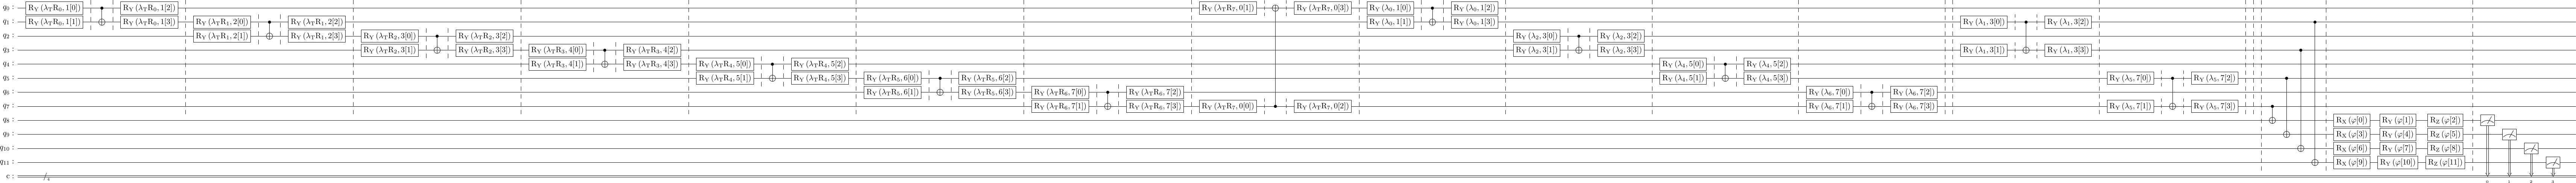

In [21]:
qc.barrier()
for i, anc in enumerate(range(n_ancilla)):
    qc.measure(anc+n_qubits, i)

qc.draw('latex', fold=1)

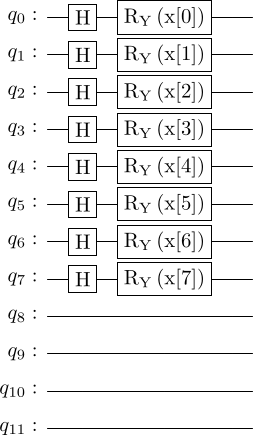

In [22]:
feature_map.draw('latex', fold=1)

In [ ]:
objective_func_vals = []

qnn = construct_qnn(
    feature_map=feature_map,
    ansatz=qc,
    callback_graph=callback_graph,
    maxiter=maxiter,
    interpret=parity,
    output_shape=output_shape,
    type_ova='vqc'
)

In [ ]:
start_time = time.time()
qnn.fit(X_train, y_train)
end_time = time.time() - start_time

m, s = divmod(total_time, 60)
h, m = divmod(m, 60)
print(f'Time fit T-AE: {round(h):>02}:{round(m):>02}:{round(s):>02}')

m, s = divmod(end_time, 60)
h, m = divmod(m, 60)
print(f'Time fit VQC: {round(h):>02}:{round(m):>02}:{round(s):>02}')


In [ ]:
y_pred = qnn.predict(X_train)
print('Classification report train')
print(classification_report(y_train, y_pred, digits=2))

print('Classification report test')
y_pred = qnn.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))


In [ ]:
keras.utils.set_random_seed(812)

model = keras.Sequential([
    l.Dense(64, activation='relu'),
    l.Dense(32, activation='relu'),
    l.Dense(output_shape, activation='softmax'),
])

y_train_categorical = pd.get_dummies(y_train)
y_test_categorical = pd.get_dummies(y_test)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
model.fit(X_train, y_train_categorical, epochs=150, verbose=0)
end = time.time()
classical = end - start

y_pred = model.predict(X_train)
y_pred = [np.argmax(i) for i in y_pred]

print(classification_report(y_train, y_pred, digits=2))

print('Classification report test')
y_pred = model.predict(X_test)
y_pred = [np.argmax(i) for i in y_pred]

print(classification_report(y_test, y_pred, digits=2))
